## Khai báo thư viện và cấu hình Reproducibility
Mục đích: Thiết lập môi trường thực thi, khai báo PyTorch, NumPy, Matplotlib và cố định random seed để kết quả thực nghiệm có thể tái lặp.

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Cố định seed cho toàn bộ hệ thống
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cpu


## Tải dữ liệu, tiền xử lý và chia tập Train/Val/Test
Mục đích: Tải tập dữ liệu diabetes.csv, tách các biến đầu vào và nhãn, phân chia thành các tập Train (70%), Validation (15%), Test (15%), và thực hiện chuẩn hóa đặc trưng (Z-score normalization) chỉ dựa trên thông số của tập Train để tránh rò rỉ dữ liệu.

In [ ]:
# Tải và kiểm tra các cột trong dữ liệu
data = pd.read_csv("../../DATA/diabetes.csv")
print("Danh sách các cột hiện tại:")
print(data.columns.tolist())
print("\nXem thử 3 dòng đầu tiên:")
display(data.head(3))

# Tự động chuyển đổi các cột không phải dạng số (chữ, object, category) sang số học
df_processed = data.copy()
for col in df_processed.columns:
    if not pd.api.types.is_numeric_dtype(df_processed[col]):
        df_processed[col] = df_processed[col].astype('category').cat.codes

# Tách đặc trưng X (tất cả các cột trừ cột cuối) và nhãn y (cột cuối cùng)
X = df_processed.iloc[:, :-1].values.astype(np.float32)
y = df_processed.iloc[:, -1].values.astype(np.int64)

N = len(X)
indices = np.random.permutation(N)

train_end = int(0.70 * N)
val_end = int(0.85 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Chuẩn hóa Z-score: mean và std chỉ tính toán trên tập Train
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Lưu lại số chiều đầu vào để dùng cho Cell 4
INPUT_DIM = X_train.shape[1]

print(f"\nSố chiều đặc trưng đầu vào (INPUT_DIM): {INPUT_DIM}")
print(f"Kích thước tập Train: {X_train.shape[0]} mẫu")
print(f"Kích thước tập Validation: {X_val.shape[0]} mẫu")
print(f"Kích thước tập Test: {X_test.shape[0]} mẫu")

## Đóng gói PyTorch Dataset và DataLoader
Mục đích: Chuyển đổi dữ liệu NumPy sang PyTorch Tensor và tạo DataLoader để nạp dữ liệu theo mini-batch (batch_size=32), hỗ trợ tối ưu hóa tham số hiệu quả.

In [5]:
# Chuyển đổi sang PyTorch Tensors
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Số lượng mini-batches trên mỗi Epoch (Train): {len(train_loader)}")

Số lượng mini-batches trên mỗi Epoch (Train): 2188


## Định nghĩa các kiến trúc mạng nơ-ron (Baseline MLP & Deeper MLP)
Mục đích: Định nghĩa lớp BaselineMLP và DeeperMLP sử dụng nn.Module kế thừa từ PyTorch, tích hợp hàm phi tuyến tính ReLU ở các tầng ẩn và trả về logits phục vụ CrossEntropyLoss. Bổ sung phương thức trích xuất biểu diễn ẩn (h). 

In [6]:
# Kiến trúc 1: Baseline MLP (d -> 64 -> C)
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=8, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(64, num_classes)
        
    def forward(self, x):
        h = self.relu(self.fc1(x))
        out = self.fc_out(h)
        return out

    def get_representation(self, x):
        return self.relu(self.fc1(x))

# Kiến trúc 2: Deeper MLP (d -> 64 -> 32 -> C)
class DeeperMLP(nn.Module):
    def __init__(self, input_dim=8, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc_out = nn.Linear(32, num_classes)
        
    def forward(self, x):
        h1 = self.relu1(self.fc1(x))
        h2 = self.relu2(self.fc2(h1))
        out = self.fc_out(h2)
        return out

    def get_representation(self, x):
        h1 = self.relu1(self.fc1(x))
        h2 = self.relu2(self.fc2(h1))
        return h2

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Tổng số tham số Baseline MLP: {count_parameters(BaselineMLP())}")
print(f"Tổng số tham số Deeper MLP: {count_parameters(DeeperMLP())}")

Tổng số tham số Baseline MLP: 706
Tổng số tham số Deeper MLP: 2722


## Xây dựng hàm huấn luyện (Training Loop) và đánh giá (Evaluation)

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Huấn luyện mô hình trong một Epoch trên toàn bộ mini-batch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
        
    return running_loss / total, correct / total


def evaluate(model, dataloader, criterion, device):
    """
    Đánh giá mô hình trên tập Validation hoặc Test (không tính gradient)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            
    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100, device=device):
    """
    Điều phối toàn bộ quá trình huấn luyện và lưu lại lịch sử qua từng Epoch
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        # In tiến trình mỗi 10 epoch
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] | "
                  f"Train Loss: {t_loss:.4f} - Train Acc: {t_acc:.4f} | "
                  f"Val Loss: {v_loss:.4f} - Val Acc: {v_acc:.4f}")
            
    return history

## Thực nghiệm 1 – Baseline MLP

In [8]:
set_seed(42)
model_exp1 = BaselineMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)

history_exp1 = train_model(model_exp1, train_loader, val_loader, criterion, optimizer_exp1, epochs=100)
print(f"Exp 1 Final Val Loss: {history_exp1['val_loss'][-1]:.4f} | Final Val Acc: {history_exp1['val_acc'][-1]:.4f}")

Exp 1 Final Val Loss: 0.0841 | Final Val Acc: 0.9719


## Thực nghiệm 2 – Deeper MLP

In [9]:
set_seed(42)
model_exp2 = DeeperMLP().to(device)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.001)

history_exp2 = train_model(model_exp2, train_loader, val_loader, criterion, optimizer_exp2, epochs=100)
print(f"Exp 2 Final Val Loss: {history_exp2['val_loss'][-1]:.4f} | Final Val Acc: {history_exp2['val_acc'][-1]:.4f}")

Exp 2 Final Val Loss: 0.0926 | Final Val Acc: 0.9713


## Thực nghiệm 3 – Optimization Experiment

In [10]:
set_seed(42)
model_exp3 = DeeperMLP().to(device)
optimizer_exp3 = optim.SGD(model_exp3.parameters(), lr=0.01, momentum=0.9)

history_exp3 = train_model(model_exp3, train_loader, val_loader, criterion, optimizer_exp3, epochs=100)
print(f"Exp 3 (SGD) Final Val Loss: {history_exp3['val_loss'][-1]:.4f} | Final Val Acc: {history_exp3['val_acc'][-1]:.4f}")

Exp 3 (SGD) Final Val Loss: 0.0851 | Final Val Acc: 0.9716


## Vẽ biểu đồ đối sánh đường cong huấn luyện (Loss & Accuracy Curves)

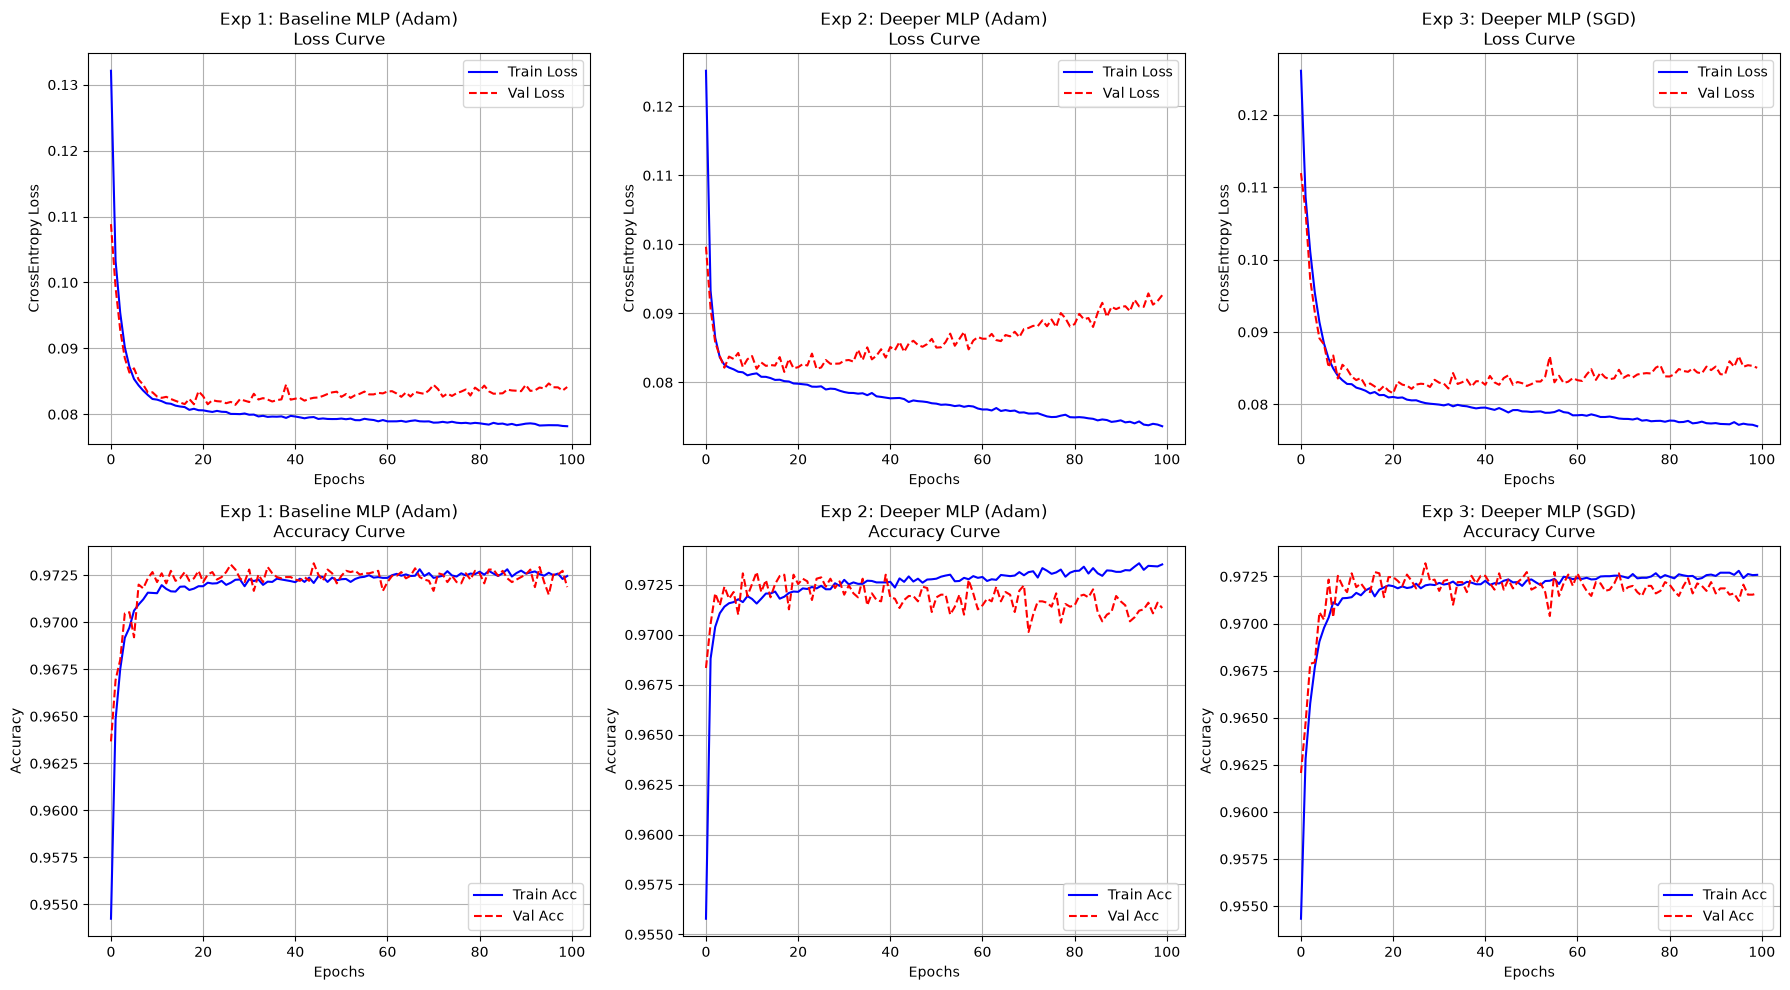

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

experiments = [
    ("Exp 1: Baseline MLP (Adam)", history_exp1),
    ("Exp 2: Deeper MLP (Adam)", history_exp2),
    ("Exp 3: Deeper MLP (SGD)", history_exp3)
]

for idx, (title, hist) in enumerate(experiments):
    # Loss curves
    axes[0, idx].plot(hist['train_loss'], label='Train Loss', color='blue')
    axes[0, idx].plot(hist['val_loss'], label='Val Loss', color='red', linestyle='--')
    axes[0, idx].set_title(f"{title}\nLoss Curve")
    axes[0, idx].set_xlabel("Epochs")
    axes[0, idx].set_ylabel("CrossEntropy Loss")
    axes[0, idx].legend()
    axes[0, idx].grid(True)
    
    # Accuracy curves
    axes[1, idx].plot(hist['train_acc'], label='Train Acc', color='blue')
    axes[1, idx].plot(hist['val_acc'], label='Val Acc', color='red', linestyle='--')
    axes[1, idx].set_title(f"{title}\nAccuracy Curve")
    axes[1, idx].set_xlabel("Epochs")
    axes[1, idx].set_ylabel("Accuracy")
    axes[1, idx].legend()
    axes[1, idx].grid(True)

plt.tight_layout()
plt.show()

## Đánh giá chi tiết trên tập Test và hiển thị Confusion Matrix

In [16]:
def compute_test_metrics(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    cm = confusion_matrix(all_targets, all_preds)
    return acc, prec, rec, f1, cm

models = {
    "Baseline MLP (Adam)": model_exp1,
    "Deeper MLP (Adam)": model_exp2,
    "Deeper MLP (SGD)": model_exp3
}

results = []
for name, m in models.items():
    acc, prec, rec, f1, cm = compute_test_metrics(m, test_loader, device)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

df_metrics = pd.DataFrame(results)
print("=== BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
print(df_metrics.to_string(index=False))

=== BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===
              Model  Accuracy  Precision   Recall  F1-Score
Baseline MLP (Adam)  0.970200   0.960172 0.685100  0.799641
  Deeper MLP (Adam)  0.969267   0.940314 0.689708  0.795747
   Deeper MLP (SGD)  0.969533   0.953813 0.682028  0.795343


## Khám phá tầng biểu diễn ẩn (Learned Representation)

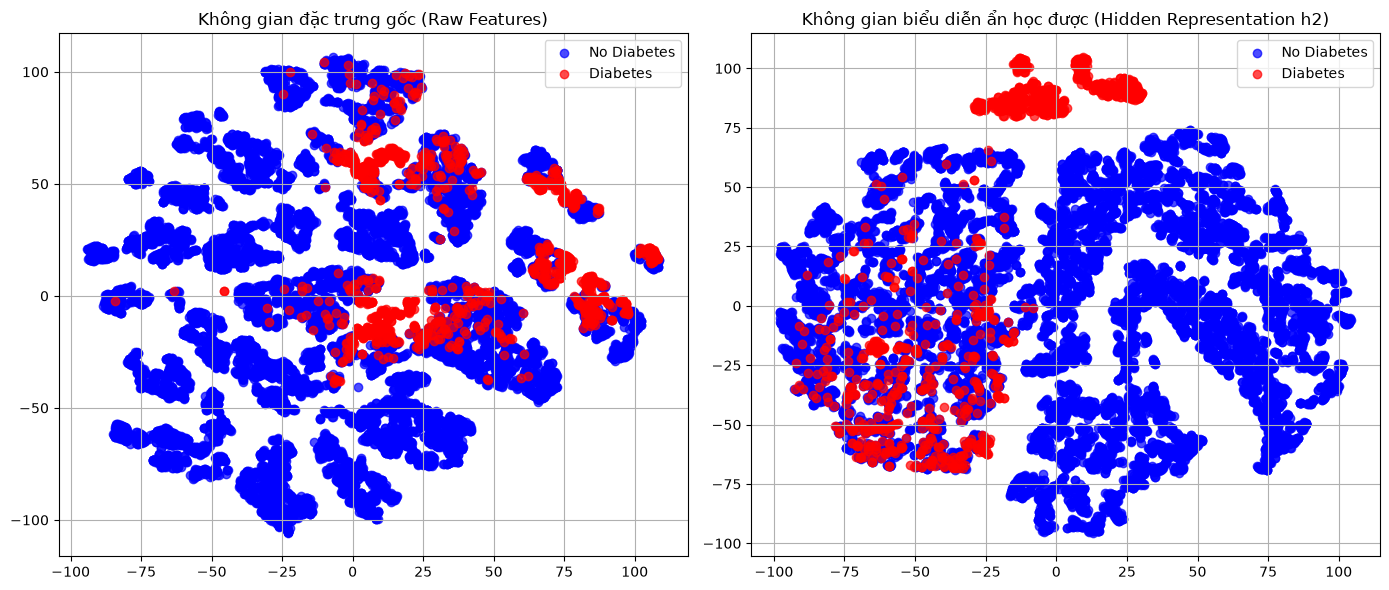

In [13]:
from sklearn.manifold import TSNE

# Lấy dữ liệu kiểm thử
X_test_tensor = torch.tensor(X_test).to(device)
with torch.no_grad():
    h_representation = model_exp2.get_representation(X_test_tensor).cpu().numpy()

# Giảm chiều xuống 2D bằng t-SNE để quan sát
tsne = TSNE(n_components=2, random_state=42)
h_2d = tsne.fit_transform(h_representation)
raw_2d = tsne.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(raw_2d[y_test == 0, 0], raw_2d[y_test == 0, 1], color='blue', alpha=0.7, label='No Diabetes')
axes[0].scatter(raw_2d[y_test == 1, 0], raw_2d[y_test == 1, 1], color='red', alpha=0.7, label='Diabetes')
axes[0].set_title("Không gian đặc trưng gốc (Raw Features)")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(h_2d[y_test == 0, 0], h_2d[y_test == 0, 1], color='blue', alpha=0.7, label='No Diabetes')
axes[1].scatter(h_2d[y_test == 1, 0], h_2d[y_test == 1, 1], color='red', alpha=0.7, label='Diabetes')
axes[1].set_title("Không gian biểu diễn ẩn học được (Hidden Representation h2)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Đóng gói và lưu trữ mô hình (Save Model State Dict)

In [17]:
# Chọn mô hình tốt nhất
BEST_MODEL_PATH = "mlp_model.pth"
torch.save(model_exp2.state_dict(), BEST_MODEL_PATH)
print(f"Đã lưu trọng số mô hình tốt nhất thành công vào: {BEST_MODEL_PATH}")

# Kiểm thử việc nạp lại mô hình từ file
loaded_model = DeeperMLP()
loaded_model.load_state_dict(torch.load(BEST_MODEL_PATH))
loaded_model.eval()

sample_input = torch.tensor(X_test[:1], dtype=torch.float32)
with torch.no_grad():
    sample_output = loaded_model(sample_input)
    predicted_prob = torch.softmax(sample_output, dim=1)
    predicted_class = torch.argmax(predicted_prob, dim=1).item()

print(f"Đoán thử mẫu 1: Xác suất = {predicted_prob.numpy()[0]}, Nhãn dự đoán = {predicted_class}")

Đã lưu trọng số mô hình tốt nhất thành công vào: mlp_model.pth
Đoán thử mẫu 1: Xác suất = [1.00000e+00 7.68478e-40], Nhãn dự đoán = 0
